In [1]:
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import deeplake 
import torch
from PIL import Image
from torchvision import transforms


class ToPILCheck:
    def __call__(self, img):
        if isinstance(img, Image.Image):
            return img

        else:
            return transforms.ToPILImage()(img)
        

class RGBCheck:
    def __call__(self, img: Image):
        return img.convert("RGB")


        
def resize(img: np.ndarray | Image.Image) -> torch.Tensor:
    
    img_transform = transforms.Compose([
        ToPILCheck(),
        RGBCheck(),
        transforms.Resize((224, 224)),
        transforms.ToTensor()])
        

    transformed = img_transform(img)

    return transformed

'''transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))'''


class patches_loader(Dataset):
    '''
    Class to handle patches stored as deeplake objects
    '''
    def __init__(self, subset, train_or_test, WSI_id, scanner, to_torch=False, emb_mode=True):
        self.subset = subset
        self.train_or_test = train_or_test
        self.WSI_id = WSI_id
        self.scanner = scanner
        self.to_torch = to_torch
        self.emb_mode = emb_mode
        
        
        if self.emb_mode:
            directory = '/home/leolr-int/nfs/transformed_data/my_embeddings'
        else:
            directory = f"/home/leolr-int/nfs/data/data/patched/dim_256/{train_or_test}"
        
        #here we consider only Subset3
        
        if self.subset == 'Subset1':
            WSI = f'{subset}_{train_or_test}_{WSI_id}'
            scanner = 'Akoya'
        else:
            WSI = f'{subset}_{train_or_test}_{WSI_id}_{scanner}'
        self.patches = deeplake.open_read_only(f'{directory}/{WSI}')

        
        #test to delete later maybe
        '''ds = deeplake.open_read_only('/home/leolr-int/nfs/transformed_data/all_embeddings')
        sql_query = f"SELECT * WHERE scanner = '{scanner}' AND subset = '{subset}' AND WSI_id = {WSI_id}"
        self.patches = ds.query(sql_query)'''

    def summary(self):
        return self.patches.summary()
    
    # to specify a label and then access the columns of the deeplake dataset
    def __getitem__(self, idx):
        if self.emb_mode:
            patch = self.patches[idx]
            embedding = torch.tensor(patch["embedding"], dtype=torch.float)
            label = torch.tensor(patch["label"], dtype=torch.long)
            return {'embedding':embedding, 'label':label} 
        
        else: 
            if self.to_torch:
                patch = self.patches[idx]
                
                img = patch["patch"].copy()
        
                '''if preprocess_fn is not None:
                    img = preprocess_fn(img)
            
                if apply_augmentation:
                    img = augment_fn(img)'''
            
                img = resize(img)
                
                #img = torch.tensor(img)
                label = torch.tensor(patch["label"], dtype=torch.long)
                area = torch.tensor(patch["area"], dtype=torch.long)
                x = torch.tensor(patch["x"], dtype=torch.long)
                y = torch.tensor(patch["y"], dtype=torch.long)
                w = torch.tensor(patch["w"], dtype=torch.long)
                h = torch.tensor(patch["h"], dtype=torch.long)
                
                metadata = {
                    "area": area,
                    "x": x,
                    "y": y,
                    "w": w,
                    "h": h,
                    }
                
                dic = {'img':img, 'label':label, 'metadata': metadata}

                if self.emb_mode:
                    # connection to embeddings
                    directory = '/home/leolr-int/nfs/transformed_data/my_embeddings'
                    
                    if self.subset == 'Subset1':
                        WSI = f'{self.subset}_{self.train_or_test}_{self.WSI_id}'
                    else:
                        WSI = f'{self.subset}_{self.train_or_test}_{self.WSI_id}_{self.scanner}'
                    embedding_ds = deeplake.open_read_only(f'{directory}/{WSI}')
                    embedding = embedding_ds[idx]['embedding']
                    embedding = torch.tensor(embedding, dtype=torch.float)
                    dic['embedding'] = embedding
                
                return dic
                
            else: 
                #deeplake object
                return self.patches[idx]
                # Example: patches[idx]['label']

    def __len__(self):
        return len(self.patches)
    
    def display(self, idx): 
        fig, axes = plt.subplots(figsize=(4, 4))
        axes.imshow(self.patches[idx]["patch"])
        plt.show()

    
    def to_embedding(self, idx=None):
        # connection to embeddings
        directory = '/home/leolr-int/nfs/transformed_data/my_embeddings'
        if self.subset == 'Subset1':
            WSI = f'{self.subset}_{self.train_or_test}_{self.WSI_id}'
        else:
            WSI = f'{self.subset}_{self.train_or_test}_{self.WSI_id}_{self.scanner}'
        embedding_ds = deeplake.open_read_only(f'{directory}/{WSI}')
        if idx == None:
            embeddings_np = np.array(embedding_ds['embedding'])  # stack into 1 array
            embeddings_tensor = torch.from_numpy(embeddings_np).float()
            return embeddings_tensor 
        else:
            embedding = embedding_ds[idx]['embedding']
            embedding = torch.tensor(embedding, dtype=torch.float)
        return embedding

 




In [2]:
#test
'''
idx=1500
file_test = patches_loader('Train', 1, 'Leica', to_torch=True)
file_test.display(idx)
file_test[idx]['img'].shape
#file_test.summary()
#print(file_test.to_embedding())
#file_test[idx]['embedding'] #use this form only when to_torch = True
#file_test.to_embedding(idx)'''


"\nidx=1500\nfile_test = patches_loader('Train', 1, 'Leica', to_torch=True)\nfile_test.display(idx)\nfile_test[idx]['img'].shape\n#file_test.summary()\n#print(file_test.to_embedding())\n#file_test[idx]['embedding'] #use this form only when to_torch = True\n#file_test.to_embedding(idx)"

In [3]:
class multi_WSI_loader(Dataset):
    '''
    Class to handle several WSI from different scanners
    Used for training a neural network
    '''

    def __init__(self, subset, WSI_ids, scanner, train_or_test='Train'):
        self.subset = subset
        self.train_or_test = train_or_test
        self.WSI_ids = WSI_ids
        self.scanner = scanner
        
        # dictionary to store all the patches_loader objects
        self.datasets = []
        
        for WSI_id in WSI_ids: 
            ds = patches_loader(subset, train_or_test, WSI_id, scanner, to_torch=True)
            _ = len(ds)
            self.datasets.append(ds)

        # index mapping
        self.index_map = []
        for ds_idx, ds in enumerate(self.datasets):
            for i in range(len(ds)):
                self.index_map.append((ds_idx, i))


    # define indexing so that the dataloader can access data    
    def __getitem__(self, idx):
        ds_idx, patch_idx = self.index_map[idx]
        return self.datasets[ds_idx][patch_idx] #which is a patches_loader object
    
    def __len__(self):
        return len(self.index_map)


def make_multi_WSI_dataset(subset, WSI_ids, scanners, train_or_test, batch_size):
    datasets = []
    
    for scanner in scanners:
        dataset = multi_WSI_loader(subset, WSI_ids, scanner, train_or_test)
        datasets.append(dataset)
    
    datasets = ConcatDataset(datasets)
    #loader = DataLoader(datasets, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)

    return datasets
    

In [4]:
# Function to randomly select 70% of indices for training and the remaining #)% for validation
def split(subset, indices, scanner, train_or_test):
    percentage=0.7
    num_sample = int(np.ceil(len(indices) * percentage))
    train_list = random.sample(indices, num_sample)
    val_list = [i for i in indices if i not in train_list]
    dataset_train = multi_WSI_loader(subset, train_list, scanner, train_or_test)
    dataset_val = multi_WSI_loader(subset, val_list, scanner, train_or_test)
    
    return (dataset_train, dataset_val)

def prep_data(list_datasets):
    datasets_train = []
    datasets_val = []
    for dataset in list_datasets:
        dataset_train, dataset_val = split(*dataset)
        datasets_train.append(dataset_train)
        datasets_val.append(dataset_val)
    datasets_train = ConcatDataset(datasets_train)
    datasets_val = ConcatDataset(datasets_val)
    loader_train = DataLoader(datasets_train, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
    loader_val = DataLoader(datasets_val, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
    return (loader_train, loader_val)

In [5]:
Test = False

if Test: 
    subset = 'Subset3'
    train_scanners = ['Akoya', 'Leica', 'KFBio']
    WSI_ids = [1,2]
    target_scanner = ['Akoya'] if 'Akoya' in train_scanners else random.choice(train_scanners)
    train_scanners.remove(target_scanner[0])
    source_scanner = train_scanners
    
    print(target_scanner)
    print(source_scanner)
    
    target_dataset = multi_WSI_loader(subset, WSI_ids, target_scanner, train_or_test='Train')
    source_dataset = multi_WSI_loader(subset, WSI_ids, source_scanner, train_or_test='Train')
    
    
    # DataLoaders
    batch_size = 16
    train_loader_source = DataLoader(source_dataset, batch_size=batch_size, shuffle=True, num_workers=4, drop_last=True, pin_memory=True)
    train_loader_target = DataLoader(target_dataset, batch_size=batch_size, shuffle=True, num_workers=4, drop_last=True, pin_memory=True)
    
    
    for batch in train_loader_source:
        images = batch['img']
        labels = batch['label']
        
        print("Source batch - Images shape:", images.shape, "Labels:", labels)
        break
    
    for batch in train_loader_target:
        images = batch['img']
        labels = batch['label']
        embeddings = batch['embedding']
        
        print("Target batch - Images shape:", images.shape, "Labels:", labels, "Emb:", embeddings)
        break

    



## Test with network handler


In [6]:
import torch
import torch.nn as nn
import random

class Network(nn.Module):
    """
    Initialises an Artificial Neural Network with the foundation encoder Gigapath 
    and 2 layers for classification (one to create embeddings, one to classify)

    """

    def __init__(self, emb_mode: bool = False, freeze_encoder: bool = True, OT: bool = False, num_classes: int = 5):
        super().__init__() #super constructor for ANN in PyTorch

        self.freeze_encoder = freeze_encoder
        self.OT = OT #maybe not useful here
        self.emb_mode = emb_mode
        
        # Define encoder

        if not self.emb_mode:
            encoder_name = 'gigapath'
            BASE_MODEL_DIR = '/home/leolr-int/AGGCPerturbations/model_weights'
            encoder_dir = os.path.join(BASE_MODEL_DIR, "pre_trained_weights")
            encoder_path = os.path.join(encoder_dir, f"{encoder_name}.pth")
            encoder = torch.load(encoder_path, map_location=torch.device("cpu"), weights_only=False)
            self.encoder = encoder

            if self.freeze_encoder:
                for param in self.encoder.parameters():
                    param.requires_grad = False
        
        else:
            #no need for the encoder
            self.encoder = None #I didnt know we could do this

        # Define bottle neck / embeddings
        # fixed parameter value for Gigapath
        in_dim = 1536
        self.bottle_neck = nn.Sequential(
            nn.Linear(in_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(), #do not forget ReLU
            nn.Dropout(p=0.5))

        # Define classification head
        out_dim = num_classes
        self.head = nn.Linear(1024, out_dim)

    # Define sequential architecture
    def forward(self, x): 
        if self.emb_mode:
            #x is  a vector here
            embedding = self.bottle_neck(x)
        else:
            #x is an image here
            if self.freeze_encoder: 
                with torch.no_grad():
                    encoded = self.encoder(x)
            else:
                encoded = self.encoder(x)
            embedding = self.bottle_neck(encoded)
        logits = self.head(embedding)
        return logits

        


In [7]:
# Training graph

def train_plot(training_stats, cm, custom_name, plot=False, OT=False):
    if OT:
        row = 3
    else:
        row = 2
    fig, axes = plt.subplots(row,2, figsize=(10,10))
    # loss curves
    axes[0,0].plot(training_stats['epoch_loss_train'], label='Training loss', color='blue')
    axes[0,0].plot(training_stats['epoch_loss_val'], label='Validation loss', color='green')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].set_title('Loss per epoch')

    # accuracy curves
    axes[0,1].plot(training_stats['epoch_balanced_accuracy_train'], label='Training accuracy', color='blue')
    axes[0,1].plot(training_stats['epoch_balanced_accuracy_val'], label='Validation accuracy', color='green')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].set_title('Accuracy per epoch')

    # time per epoch
    axes[1,0].plot(training_stats['time'], color='black')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Time')
    axes[1,0].set_title('Time for each epoch')

    # confusion matrix
    label_name = ['Stroma', 'Normal', 'G3', 'G4', 'G5']
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_name)
    display.plot(ax=axes[1,1], cmap='PuRd', colorbar=False)
    axes[1,1].set_title('Confusion matrix for validation')

    if OT:
        axes[2,0].plot(training_stats['CE_target_val'], label='CE Akoya', color='blue')
        axes[2,0].plot(training_stats['CE_source_val'], label='CE Leica', color='green')
        axes[2,0].plot(training_stats['OT_loss_val'], label='OT', color='red')
        axes[2,0].set_xlabel('Epoch')
        axes[2,0].set_ylabel('Losses')
        axes[2,0].legend()
        axes[2,0].set_title('Decomposed validation loss')

        axes[2,1].plot(training_stats['acc_target'], label='Akoya accuracy', color='blue')
        axes[2,1].plot(training_stats['acc_source'], label='Leica accuracy', color='green')
        axes[2,1].set_xlabel('Epoch')
        axes[2,1].set_ylabel('Accuracy')
        axes[2,1].legend()
        axes[2,1].set_title('Validation accuracies of target and source per epoch')

    plt.suptitle('Training statistics')
    fig.tight_layout()
    if plot:
        plt.show()
    plt.savefig(f'training_stats_{custom_name}.pdf')
    plt.close(fig)

In [8]:
def save_checkpoint(
    save_dir,
    custom_name,
    model,
    optimizer,
    scheduler,
    epoch,
    balanced_accuracy,
    loss,
    min_loss_val,
    max_accuracy_val):

    os.makedirs(f'{save_dir}/{custom_name}', exist_ok=True)

    training_state = {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'epoch': epoch,
        'balanced_accuracy': balanced_accuracy,
        'loss': loss,
        'min_loss_val': min_loss_val,
        'max_accuracy_val': max_accuracy_val
    }

    torch.save(training_state, os.path.join(save_dir, custom_name, f'checkpoint.pth'))

# i have to give a custom_name

def end_epoch(
    save_dir,
    custom_name,
    model,
    optimizer,
    scheduler,
    epoch,
    epoch_loss_train,
    epoch_balanced_accuracy_train,
    epoch_loss_val,
    epoch_balanced_accuracy_val,
    min_loss_val,
    max_accuracy_val,
):
    save_checkpoint(
        save_dir=save_dir,
        custom_name=custom_name,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        epoch=epoch,
        balanced_accuracy=epoch_balanced_accuracy_val,
        loss=epoch_loss_val,
        min_loss_val =min_loss_val,
        max_accuracy_val=max_accuracy_val,
    )

    if epoch_loss_val < min_loss_val:
        torch.save(model.state_dict(), os.path.join(save_dir, custom_name, f'lowest_loss.pth'))
        min_loss_val = epoch_loss_val
        print(f'Epoch {epoch}: new minimum for val loss = {min_loss_val}')
    if epoch_balanced_accuracy_val > max_accuracy_val:
        torch.save(model.state_dict(), os.path.join(save_dir, custom_name, f'max_accuracy.pth'))
        max_accuracy_val = epoch_balanced_accuracy_val
        print(f'Epoch {epoch}: new maximum for val accuracy = {max_accuracy_val}')
                   

    return min_loss_val, max_accuracy_val



In [9]:
from umap import UMAP

def better_confusion_matrix(custom_name, y_true, y_pred, scanner, acc_score):
    label_name = ['Stroma', 'Normal', 'G3', 'G4', 'G5']
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4], normalize='true')
    #?
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    #?
    recalls = recall_score(y_true, y_pred, average=None, zero_division=0)
    precisions = precision_score(y_true, y_pred, average=None, zero_division=0)

    df = pd.DataFrame(cm, index=label_name, columns=label_name)
    df['recall'] = recalls
    df_perc = pd.DataFrame(cm_perc, index=label_name, columns=label_name)
    df_perc['precision'] = precisions

    precisions = list(precisions) + [np.nan] #this is a filler for the bottom left corner
    df.loc['precision'] = precisions
    df_perc.loc['precision'] = precisions


    fig, ax = plt.subplots(figsize=(6,6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_name)
    disp.plot(ax=ax, cmap='PuRd')
    #display percentage
    '''for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            disp.text_[i,j].set_text(cm_perc[i,j])'''
    
    plt.title(f'Confusion matrix using {custom_name} for {scanner} \n balanced accuracy = {round(acc_score*100, 2)}%')
    plt.plot()
    plt.savefig(f'/home/leolr-int/nfs/transformed_data/weights/{custom_name}/confusion_matrix_{scanner}.pdf')
    
    return df, df_perc

def dim_reduc_plot(embeddings, y_true, scanner, custom_name, n_components=2):
    
    umap = UMAP(n_components=2, init='random', random_state=42, verbose=True)
    with open(f'/home/leolr-int/nfs/transformed_data/weights/{custom_name}/umap_{scanner}_axis.pkl', 'wb') as f:
        pickle.dump(umap, f)
    reduced = umap.fit_transform(embeddings)
    
    label_map = {0:'Stroma', 1:'Normal', 2:'G3', 3:'G4', 4:'G5'}
    labels = [label_map[y] for y in y_true]    
    
    plt.figure(figsize=(6,6))
    palette = sns.color_palette("colorblind")
    ax = sns.scatterplot(
        x=reduced[:,0], 
        y=reduced[:,1], 
        hue=labels, 
        palette=palette, 
        alpha=0.6, 
        s=20
    )
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, title='Labels')
    
    plt.legend(title="Label", labels=['Normal', 'Stroma', 'G3', 'G4', 'G5'], loc="upper left")
    plt.title(f'UMAP plot for {scanner}')
    plt.savefig(f'/home/leolr-int/nfs/transformed_data/weights/{custom_name}/umap_{scanner}.png')
    plt.plot()

    #usage example:
    '''with open('umap_{scanner}_axis.pkl', 'rb') as f:
        loaded_umap = pickle.load(f)
    new_reduced = loaded_umap.transform(new_embeddings)'''

   

/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
import os
from typing import (
    Tuple, 
    Literal
)
import random
import torch
import numpy as np
import torch.nn as nn
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import GradScaler
from torch.utils.data import DataLoader
import deeplake
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
from sklearn.decomposition import PCA
from geomloss import SamplesLoss
import time
import pandas as pd
from torch.utils.data import ConcatDataset, RandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
import pickle
import seaborn as sns
import itertools

# Ensuring reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(42)
random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False 

# Define global variables
#metrics_train = {'running_loss':0, 'predictions':[], 'labels':[]}
#metrics_val = {'running_loss':0, 'predictions':[], 'labels':[]}


# Defining OT-based loss function
loss_geom = SamplesLoss('sinkhorn', p=2, blur=0.1, scaling=0.95, verbose=False)
Lambda = 0.1 # strength of OT (0.1 is the value of the article)

class NetworkHandler:
    '''
    A class to handle training, inference and prediction
    '''

    def __init__(self, precision = 'mixed', freeze_encoder = True, emb_mode = False, display = False):
        self.precision = precision
        self.freeze_encoder = freeze_encoder
        self.emb_mode = emb_mode
        self.display = display

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.model = Network(emb_mode=self.emb_mode)
        self.model = self.model.to(self.device, non_blocking=True)

        #printing architecture
        '''print("Bottleneck layers:")
        print(self.model.bottle_neck)
        print("Head layer:")
        print(self.model.head)
        if self.model.encoder is not None:
            print("\nEncoder architecture:")
            print(self.model.encoder)'''

        self.use_amp = precision == 'mixed' and self.device == 'cuda'
        self.grad_scaler = GradScaler(enabled=self.use_amp)

    
    def training_no_OT(self, batch_size, num_epochs):
        # here we train only using cross entropy
        training_stats = []
        min_loss_val, max_accuracy_val = float("inf"), -float("inf")

        trainable_params = list(filter(lambda p: p.requires_grad, self.model.parameters()))
        optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        idx_range_subset1 = [i for i in range(1,52+1)] #only the 26 first slides
        random.shuffle(idx_range_subset1)
        num_train = int(np.ceil(0.7 * len(idx_range_subset1))) 
        train_range1, val_range1 = idx_range_subset1[:num_train], idx_range_subset1[num_train:]
        
        idx_range_subset3 = [i for i in range(1,26+1)] 
        random.shuffle(idx_range_subset3)
        num_train = int(np.ceil(0.7 * len(idx_range_subset3))) 
        train_range3, val_range3 = idx_range_subset3[:num_train], idx_range_subset3[num_train:]
    
        akoya_loader_train_subset1 = make_multi_WSI_loader('Subset1', train_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
        akoya_loader_val_subset1 = make_multi_WSI_loader('Subset1', val_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
        akoya_loader_train_subset3 = make_multi_WSI_loader('Subset3', train_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
        akoya_loader_val_subset3 = make_multi_WSI_loader('Subset3', val_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
        leica_loader_train = make_multi_WSI_loader('Subset3', train_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
        leica_loader_val = make_multi_WSI_loader('Subset3', val_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
    
        loader_train = ConcatDataset([akoya_loader_train_subset1.dataset, akoya_loader_train_subset3.dataset, leica_loader_train.dataset])
        loader_val = ConcatDataset([akoya_loader_val_subset1.dataset, akoya_loader_val_subset3.dataset, leica_loader_val.dataset])
    
        loader_train = DataLoader(loader_train, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
        loader_val = DataLoader(loader_val, batch_size=batch_size, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
            
        len_loader_train = len(loader_train)
        len_loader_val = len(loader_val)

        for epoch in range(1, num_epochs+1):
            

            metrics_train = {'running_loss': 0, 'predictions': [], 'labels': []}
            metrics_val   = {'running_loss': 0, 'predictions': [], 'labels': []}
            
            start = time.time()
            # 1st part: training for one epoch 
            self.model.train()
    
            #deactivate the encoder training if needed
            if self.freeze_encoder and not self.emb_mode: 
                self.model.encoder.eval()
            
            pbar = tqdm(loader_train, desc=f'Epoch:{epoch} Training with Cross-Entropy in progress')
            
            for batch in pbar:
                batch_train_start = time.time()
                
                patch = batch['embedding'] if self.emb_mode else batch['img'] 
                patch = patch.to(self.device, non_blocking=True)
                label = batch['label'].to(self.device, non_blocking=True)

                optimizer.zero_grad()
    
                with torch.autocast(device_type = self.device, dtype = torch.float16, enabled = self.use_amp):
                    #if embeddings from gigapath are already computed, we can speed up training
                    logits = self.model(patch) 
                    loss = nn.CrossEntropyLoss()(logits, label) #careful about syntax
                
                self.grad_scaler.scale(loss).backward()
                self.grad_scaler.step(optimizer)
                self.grad_scaler.update()
                
    
                confidence = F.softmax(logits, dim=1)
                pred = torch.argmax(confidence, dim=1)
                
                #performance metrics
                metrics_train['running_loss'] += loss.detach().item()
                metrics_train['predictions'].extend(pred.cpu().numpy())
                metrics_train['labels'].extend(label.cpu().numpy())
                
                
    
                #pbar.set_postfix({'step_loss': loss.detach().item()})
                
            
            epoch_loss_train = metrics_train['running_loss'] / len_loader_train
            epoch_balanced_accuracy_train = balanced_accuracy_score(metrics_train['labels'], metrics_train['predictions'])
            

            
            
            # 2nd part: validation for one epoch 
            with torch.no_grad():
                self.model.eval()
                
                #we still work with the Train folder
                
                pbar = tqdm(loader_val, desc=f'Epoch:{epoch} Validation - Cross-Entropy in progress')
                for batch in pbar:
                    patch = batch['embedding'] if self.emb_mode else batch['img']
                    patch = patch.to(self.device, non_blocking=True) 
                    label = batch['label'].to(self.device, non_blocking=True)

                    with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                        logits = self.model(patch)
                        loss = nn.CrossEntropyLoss()(logits, label)
                    
                    confidence = F.softmax(logits, dim=1)
                    pred = torch.argmax(confidence, dim=1)
        
                    metrics_val["running_loss"] += loss.detach().item()
                    metrics_val["predictions"].extend(pred.cpu().numpy())
                    metrics_val["labels"].extend(label.cpu().numpy())
        
                    #pbar.set_postfix({"step_loss": loss.detach().item()})
        
                epoch_loss_val = metrics_val["running_loss"] / len_loader_val
                epoch_balanced_accuracy_val = balanced_accuracy_score(metrics_val["labels"], metrics_val["predictions"])

                scheduler.step(epoch_loss_val) 
                
                cm = confusion_matrix(metrics_val["labels"], metrics_val["predictions"], labels=[0, 1, 2, 3, 4], normalize='true')
    
                end = time.time()
    
                dic = {'epoch_loss_train': epoch_loss_train, 
                    'epoch_balanced_accuracy_train': epoch_balanced_accuracy_train, 
                    'epoch_loss_val': epoch_loss_val, 
                    'epoch_balanced_accuracy_val': epoch_balanced_accuracy_val, 
                    'time': end - start,
                    'cm':cm}
                
                training_stats.append(dic)

                min_loss_val, max_accuracy_val = end_epoch(
                                                    save_dir,
                                                    custom_name,
                                                    self.model,
                                                    optimizer,
                                                    scheduler,
                                                    epoch,
                                                    epoch_loss_train,
                                                    epoch_balanced_accuracy_train,
                                                    epoch_loss_val,
                                                    epoch_balanced_accuracy_val,
                                                    min_loss_val,
                                                    max_accuracy_val)
                
                train_plot(pd.DataFrame(training_stats), cm, custom_name=custom_name)
                torch.cuda.empty_cache()

                
            
        return epoch_loss_val, epoch_balanced_accuracy_val

    @torch.no_grad()
    def extract_embeddings(self, subset, scanners, WSI_ids, train_or_test, batch_size):
        # creates the deeplake database for embeddings
        # structure: one deeplake dataset per WSI, embeddings, scanner, WSI_id, Train or Test

        root_dir = '/home/leolr-int/nfs/transformed_data/my_embeddings'
        self.model.eval()
        if subset == 'Subset1':
            scanners = 'Akoya'
        for scanner in scanners:
            for id in WSI_ids:
                if subset == 'Subset1':
                    path = f'{subset}_{train_or_test}_{id}'
                else:
                    path = f'{subset}_{train_or_test}_{id}_{scanner}'
                final_destination = os.path.join(root_dir, path)
                os.makedirs(final_destination, exist_ok=True)
                # creation of the deeplake dataset
                embedding_ds = deeplake.create(final_destination)
                embedding_ds.add_column('embedding', dtype=deeplake.types.Embedding(1536)) 
                embedding_ds.add_column('subset', dtype=deeplake.types.Text)
                embedding_ds.add_column('scanner', dtype=deeplake.types.Text)
                embedding_ds.add_column('WSI_id', deeplake.types.Int32)
                embedding_ds.add_column('train_or_test', dtype=deeplake.types.Text)
                embedding_ds.add_column('label', dtype=deeplake.types.Int32)

                WSI = patches_loader(subset, train_or_test, id, scanner, to_torch=True, emb_mode=False)
                loader = DataLoader(WSI, batch_size=batch_size, shuffle=False, num_workers=6, pin_memory=True)
                batch_records = []

                for batch in tqdm(loader, desc=f'Extracting {path}'):
                    patches = batch['img'].to(self.device).float()
                    labels = batch['label']

                    with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                        embeddings = self.model.encoder(patches)
                        embeddings = embeddings.detach().cpu().numpy()

                        # accumulate all rows from batch
                        for emb, label in zip(embeddings, labels):
                            batch_records.append({
                                'embedding':emb,
                                'subset': subset,
                                'WSI_id': id, 
                                'scanner': 'Akoya' if subset == 'Subset1' else scanner,
                                'train_or_test': train_or_test,
                                'label': label
                            })

                        # append in large
                        if len(batch_records) >= 1000:
                            embedding_ds.append(batch_records)
                            batch_records.clear()

                    # append what is left
                    if batch_records:
                        embedding_ds.append(batch_records)
                    
                
    @torch.no_grad()
    def inference(self, custom_name, scanner, data_loader, visual=True):
        weights = f'/home/leolr-int/nfs/transformed_data/weights/{custom_name}/checkpoint.pth'
        checkpoint = torch.load(weights, weights_only=False, map_location=self.device)
        handler.model.load_state_dict(checkpoint["model"])        
        
        self.model.eval()
        all_preds, all_labels, all_embeddings = [], [], []
        for batch in tqdm(data_loader, desc='Inference in progress...'):
            vectors= batch['embedding'].to(self.device)
            labels = batch['label'].to(self.device)
            emb = self.model.bottle_neck(vectors)
            with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                logits = self.model.head(emb)
                
            confidence = F.softmax(logits, dim=1)
            pred = torch.argmax(confidence, dim=1)
            
            all_preds.append(pred.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_embeddings.append(emb.cpu().numpy())
        
        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate (all_labels)
        all_embeddings = np.concatenate(all_embeddings)

        acc_score = balanced_accuracy_score(all_labels, all_preds)
        print(acc_score)

        CM = better_confusion_matrix(custom_name, all_labels, all_preds, scanner, acc_score)
        if visual:
            #random selection of 20% of the sample
            N = all_embeddings.shape[0]
            sample_size = int(0.2 * N)
            indices = torch.randperm(N)[:sample_size]
            sampled_embeddings = all_embeddings[indices]
            sampled_labels = all_labels[indices]
            dim_reduc_plot(embeddings=sampled_embeddings, y_true=sampled_labels, scanner=scanner, custom_name=custom_name, n_components=2)


    def training_OT(self, batch_size, num_epochs): 
        # we differentiate explicitly source and target scanner to apply the OT loss
        # training with validation

        training_stats = []
        min_loss_val, max_accuracy_val = float("inf"), -float('inf')
        
        min_len_train = min(len(akoya_loader_train), len(leica_loader_train))
        min_len_val = min(len(akoya_loader_val), len(leica_loader_val))
        
        trainable_params = list(filter(lambda p: p.requires_grad, self.model.parameters()))
        optimizer = torch.optim.AdamW(trainable_params, lr=10e-4, weight_decay=0.01)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        
        #Data loading (parallelise Akoya and Leica data loaders with resampling for Leica)
        # if this works, delete "optimised loader" (useless)
        
        

        for epoch in range(1,num_epochs+1):
            metrics_train = {'running_loss': 0, 'predictions': [], 'labels': []}
            metrics_val   = {'running_loss': 0, 
                             'predictions': [], 
                             'predictions_akoya':[],
                             'predictions_leica':[],
                             'labels_akoya':[],
                             'labels_leica':[],
                             'labels': [], 
                             'CE_target_val':0,
                            'CE_source_val':0,
                            'OT_loss_val':0,
                            'acc_target_val':0,
                            'acc_source_val':0}
            
            
            start = time.time()
            
            #1st part: train for one epoch
            self.model.train()

            #deactivate the encoder training if needed
            if self.freeze_encoder and not self.emb_mode:
                self.model.encoder.eval()

            #the target scanner is Akoya
 
            for batch_akoya, batch_leica in tqdm(zip(akoya_loader_train, leica_loader_train),
                                                desc=f"Epoch {epoch} Training - OT in progress",
                                                total=min_len_train):
            #for batch_akoya in tqdm(akoya_loader_train, desc=f'Epoch {epoch} Training - Optimal Transport in progress'):
                #batch_leica = next(leica_train_iter)

                patches_akoya = (batch_akoya['embedding'] if self.emb_mode else batch_akoya['img']).to(self.device, non_blocking=True)
                patches_leica = (batch_leica['embedding'] if self.emb_mode else batch_leica['img']).to(self.device, non_blocking=True)
                labels_akoya = batch_akoya['label'].to(self.device, non_blocking=True)
                labels_leica = batch_leica['label'].to(self.device, non_blocking=True)

                optimizer.zero_grad()
    
                with torch.autocast(device_type = self.device, dtype = torch.float16, enabled = self.use_amp):
                    #if embeddings from gigapath are already computed, we can speed up training
                    #the name embedding is ambiguous, in "batch_akoya['embedding']" it refers to Gigapath, in the line below it refers to my model with bottleneck
                    embedding_akoya = self.model.bottle_neck(patches_akoya).to(self.device, non_blocking=True)
                    embedding_leica = self.model.bottle_neck(patches_leica).to(self.device, non_blocking=True)
                    logits_akoya = self.model(patches_akoya).to(self.device, non_blocking=True) 
                    logits_leica = self.model(patches_leica).to(self.device, non_blocking=True)
                    
                    # loss function
                    loss_train = ( nn.CrossEntropyLoss()(logits_akoya, labels_akoya) #to avoid that the model specialises in Akoya
                                  +  nn.CrossEntropyLoss()(logits_leica, labels_leica) 
                                  + Lambda * loss_geom(embedding_akoya.detach().squeeze(), embedding_leica.squeeze()) 
                                 )
                    #coefficient in front of Leica Cross Entropy to compensate for the resampling
                    # detach on Leica because we want to penalize for the wrong representation of Leica and migrate it to Akoya
                self.grad_scaler.scale(loss_train).backward()
                self.grad_scaler.step(optimizer)
                self.grad_scaler.update()
                
    
                confidence_akoya = F.softmax(logits_akoya, dim=1)
                confidence_leica = F.softmax(logits_leica, dim=1)
                pred_akoya = torch.argmax(confidence_akoya, dim=1)
                pred_leica = torch.argmax(confidence_leica, dim=1)
                
                #performance metrics
                #performance metrics
                metrics_train['running_loss'] += loss_train.detach().cpu().item()
                # we concatenate the predictions of source and target
                metrics_train['predictions'].extend(pred_akoya.cpu().numpy())
                metrics_train['predictions'].extend(pred_leica.cpu().numpy())
                metrics_train['labels'].extend(labels_akoya.cpu().numpy())
                metrics_train['labels'].extend(labels_leica.cpu().numpy())

                
            
            epoch_loss_train = metrics_train['running_loss'] / min_len_train 
            epoch_balanced_accuracy_train = balanced_accuracy_score(metrics_train['labels'], metrics_train['predictions'])
                
                
          
            # 2nd part: validation for one epoch 
            with torch.no_grad():
                self.model.eval()
                
                #we still work with the Train folder
                
                for batch_akoya_val, batch_leica_val in tqdm(zip(akoya_loader_val, leica_loader_val),
                                                desc=f"Epoch {epoch} Validation - OT in progress",
                                                total=min_len_val):

                    patches_akoya_val = (batch_akoya_val['embedding'] if self.emb_mode else batch_akoya_val['img']).to(self.device, non_blocking=True)
                    patches_leica_val = (batch_leica_val['embedding'] if self.emb_mode else batch_leica_val['img']).to(self.device, non_blocking=True)
                    labels_akoya_val = batch_akoya_val['label'].to(self.device, non_blocking=True)
                    labels_leica_val = batch_leica_val['label'].to(self.device, non_blocking=True)

                    with torch.autocast(device_type=self.device, dtype=torch.float16, enabled=self.use_amp):
                        embedding_akoya_val = self.model.bottle_neck(patches_akoya_val).to(self.device, non_blocking=True)
                        embedding_leica_val = self.model.bottle_neck(patches_leica_val).to(self.device, non_blocking=True)
                        logits_akoya_val = self.model(patches_akoya_val).to(self.device, non_blocking=True)
                        logits_leica_val = self.model(patches_leica_val).to(self.device, non_blocking=True)
                        
                        CE_target_val = nn.CrossEntropyLoss()(logits_akoya_val, labels_akoya_val)
                        CE_source_val = nn.CrossEntropyLoss()(logits_leica_val, labels_leica_val)
                        OT_loss_val = loss_geom(embedding_akoya_val.detach().squeeze(), embedding_leica_val.detach().squeeze())
                        loss_val = (
                            CE_target_val #to avoid that the model specialises in Akoya
                            + CE_source_val
                            + Lambda * OT_loss_val
                        )
                        #here we detach both because we do not compute the gradient
                    
                    confidence_akoya_val = F.softmax(logits_akoya_val, dim=1)
                    confidence_leica_val = F.softmax(logits_leica_val, dim=1)
                    pred_akoya_val = torch.argmax(confidence_akoya_val, dim=1)
                    pred_leica_val = torch.argmax(confidence_leica_val, dim=1)

                    # Update validation metrics
                    metrics_val['running_loss'] += loss_val.detach().cpu().item()
                    metrics_val['predictions_akoya'].extend(pred_akoya_val.cpu().numpy())
                    metrics_val['predictions'].extend(pred_akoya_val.cpu().numpy())
                    metrics_val['predictions_leica'].extend(pred_leica_val.cpu().numpy())
                    metrics_val['predictions'].extend(pred_leica_val.cpu().numpy())
                    metrics_val['labels_akoya'].extend(labels_akoya_val.cpu().numpy())
                    metrics_val['labels'].extend(labels_akoya_val.cpu().numpy())
                    metrics_val['labels_leica'].extend(labels_leica_val.cpu().numpy())
                    metrics_val['labels'].extend(labels_leica_val.cpu().numpy())
                    metrics_val['CE_target_val'] += CE_target_val.detach().cpu().item()
                    metrics_val['CE_source_val'] += CE_source_val.detach().cpu().item()
                    metrics_val['OT_loss_val'] += OT_loss_val.detach().cpu().item()
        
        
                epoch_loss_val = metrics_val['running_loss'] / min_len_val
                
                epoch_balanced_accuracy_val = balanced_accuracy_score(metrics_val['labels'], metrics_val['predictions'])
                
                scheduler.step(epoch_loss_val) 
                
                cm = confusion_matrix(metrics_val["labels"], metrics_val["predictions"], labels=[0, 1, 2, 3, 4], normalize='true')
    
                end = time.time()
    
                dic = {'epoch_loss_train': epoch_loss_train, 
                    'epoch_balanced_accuracy_train': epoch_balanced_accuracy_train, 
                    'epoch_loss_val': epoch_loss_val, 
                    'epoch_balanced_accuracy_val': epoch_balanced_accuracy_val, 
                    'time': end - start,
                    'cm':cm,
                    'CE_target_val': metrics_val['CE_target_val'] / min_len_val,
                    'OT_loss_val': metrics_val['OT_loss_val'] / min_len_val,
                    'CE_source_val': metrics_val['CE_source_val'] / min_len_val,
                    'acc_target': balanced_accuracy_score(metrics_val['labels_akoya'], metrics_val['predictions_akoya']),
                    'acc_source': balanced_accuracy_score(metrics_val['labels_leica'], metrics_val['predictions_leica'])
                      }
                
                training_stats.append(dic)

                min_loss_val, max_accuracy_val = end_epoch(
                                                    save_dir,
                                                    custom_name,
                                                    self.model,
                                                    optimizer,
                                                    scheduler,
                                                    epoch,
                                                    epoch_loss_train,
                                                    epoch_balanced_accuracy_train,
                                                    epoch_loss_val,
                                                    epoch_balanced_accuracy_val,
                                                    min_loss_val,
                                                    max_accuracy_val)
                
                train_plot(pd.DataFrame(training_stats), cm, custom_name=custom_name, OT=True)
                torch.cuda.empty_cache()

                
            
        return epoch_loss_val, epoch_balanced_accuracy_val


        


In [11]:
# Ultra-fast for debugging
'''
class FakeDataset(Dataset):
    def __init__(self, num_samples=100, embedding_dim=1536, img_shape=(3, 224, 224), num_classes=5):
        """
        Create a fake dataset for fast testing
        
        Args:
            num_samples: Number of samples in the dataset
            embedding_dim: Dimension of embeddings (1536 as specified)
            img_shape: Shape of images if not using embedding mode
            num_classes: Number of classes (0-4 based on your confusion matrix)
        """
        self.num_samples = num_samples
        self.embedding_dim = embedding_dim
        self.img_shape = img_shape
        self.num_classes = num_classes
        
        # Pre-generate all data to make it super fast
        self.embeddings = torch.randn(num_samples, embedding_dim)
        self.images = torch.randn(num_samples, *img_shape)
        self.labels = torch.randint(0, num_classes, (num_samples,))
    
    def __len__(self):
        return self.num_samples
    
    def __getitem__(self, idx):
        return {
            'embedding': self.embeddings[idx],
            'img': self.images[idx], 
            'label': self.labels[idx]
        }

def create_fast_fake_dataloaders(batch_size=32, train_samples=200, val_samples=50):
    """
    Replace your entire data loading section with this for fast testing
    """
    print('Loading starting... (FAKE DATA)')
    
    # Create fake datasets
    akoya_train_fake = FakeDataset(num_samples=train_samples)
    akoya_val_fake = FakeDataset(num_samples=val_samples)
    leica_train_fake = FakeDataset(num_samples=train_samples) 
    leica_val_fake = FakeDataset(num_samples=val_samples)
    
    # Mimic your concatenation structure
    akoya_loader_train = ConcatDataset([akoya_train_fake, akoya_train_fake])  # Concat with itself
    akoya_loader_val = ConcatDataset([akoya_val_fake, akoya_val_fake])
    
    len_train = len(akoya_loader_train)
    len_val = len(akoya_loader_val)
    len_leica_train = len(leica_train_fake)
    len_leica_val = len(leica_val_fake)
    
    # Create DataLoaders (fix the bug from your original code)
    akoya_loader_train = DataLoader(akoya_loader_train, batch_size=batch_size, shuffle=True, 
                                   num_workers=0, pin_memory=True)  # num_workers=0 for faster testing
    akoya_loader_val = DataLoader(akoya_loader_val, batch_size=batch_size, shuffle=True, 
                                 num_workers=0, pin_memory=True)
    
    # Fixed Leica loaders (remove the .dataset at the end!)
    leica_loader_train = DataLoader(leica_train_fake, batch_size=batch_size, num_workers=0, 
                                   pin_memory=True,
                                   sampler=RandomSampler(leica_train_fake, replacement=True, 
                                                       num_samples=len_train))
    leica_loader_val = DataLoader(leica_val_fake, batch_size=batch_size, num_workers=0, 
                                 pin_memory=True,
                                 sampler=RandomSampler(leica_val_fake, replacement=True, 
                                                     num_samples=len_val))
    
    print('... Loading finished (FAKE DATA)')
    
    return (akoya_loader_train, akoya_loader_val, leica_loader_train, leica_loader_val, 
            len_train, len_val, len_leica_train, len_leica_val)

akoya_loader_train, akoya_loader_val, leica_loader_train, leica_loader_val, len_train, len_val, len_leica_train, len_leica_val = create_fast_fake_dataloaders(batch_size=32, train_samples=50, val_samples=20)

'''

'\nclass FakeDataset(Dataset):\n    def __init__(self, num_samples=100, embedding_dim=1536, img_shape=(3, 224, 224), num_classes=5):\n        """\n        Create a fake dataset for fast testing\n\n        Args:\n            num_samples: Number of samples in the dataset\n            embedding_dim: Dimension of embeddings (1536 as specified)\n            img_shape: Shape of images if not using embedding mode\n            num_classes: Number of classes (0-4 based on your confusion matrix)\n        """\n        self.num_samples = num_samples\n        self.embedding_dim = embedding_dim\n        self.img_shape = img_shape\n        self.num_classes = num_classes\n\n        # Pre-generate all data to make it super fast\n        self.embeddings = torch.randn(num_samples, embedding_dim)\n        self.images = torch.randn(num_samples, *img_shape)\n        self.labels = torch.randint(0, num_classes, (num_samples,))\n\n    def __len__(self):\n        return self.num_samples\n\n    def __getitem__(s

In [12]:
extract = False
if extract:
    #KFBio not done yet
    subset = 'Subset3'
    scanners = ['Akoya', 'KFBio']
    train_or_test = 'Test'
    WSI_ids = [i for i in range(1,26+1)] #all the patients downloaded
    batch_size = 128
    NetworkHandler(emb_mode=False).extract_embeddings(subset, scanners, WSI_ids, train_or_test, batch_size)

    

    #verification 
    
    embedding_1_KFBio = deeplake.open_read_only('/home/leolr-int/nfs/transformed_data/my_embeddings/Subset3_Test_1_KFBio')
    print(embedding_1_KFBio.summary())
    print(embedding_1_KFBio[0]['embedding'], embedding_1_KFBio[0]['label'])

In [13]:
#lui fonction top !!!!!!!!!!!
train = False
if train:
    
    batch_size = 64 

    print('Loading starting...')
    idx_range_subset1 = [i for i in range(1,52+1)]
    random.shuffle(idx_range_subset1)
    num_train = int(np.ceil(0.7 * len(idx_range_subset1))) 
    train_range1, val_range1 = idx_range_subset1[:num_train], idx_range_subset1[num_train:]
    
    idx_range_subset3 = [i for i in range(1,26+1)] 
    random.shuffle(idx_range_subset3)
    num_train = int(np.ceil(0.7 * len(idx_range_subset3))) 
    train_range3, val_range3 = idx_range_subset3[:num_train], idx_range_subset3[num_train:]
    
    akoya_loader_train_subset1 = make_multi_WSI_dataset('Subset1', train_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
    akoya_loader_val_subset1 = make_multi_WSI_dataset('Subset1', val_range1, ['Akoya'], train_or_test='Train', batch_size=batch_size)
    akoya_loader_train_subset3 = make_multi_WSI_dataset('Subset3', train_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
    akoya_loader_val_subset3 = make_multi_WSI_dataset('Subset3', val_range3, ['Akoya'], train_or_test='Train', batch_size=batch_size)
    leica_loader_train = make_multi_WSI_dataset('Subset3', train_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
    leica_loader_val = make_multi_WSI_dataset('Subset3', val_range3, ['Leica'], train_or_test='Train', batch_size=batch_size)
    
    akoya_loader_train = ConcatDataset([akoya_loader_train_subset1, akoya_loader_train_subset3])
    akoya_loader_val = ConcatDataset([akoya_loader_val_subset1, akoya_loader_val_subset3])
    
    len_akoya_train = len(akoya_loader_train)
    len_akoya_val = len(akoya_loader_val)
    
    len_leica_train = len(leica_loader_train)
    len_leica_val = len(leica_loader_val)
    
    len_train = len_akoya_train + len_leica_train
    len_val = len_akoya_val + len_leica_val
    
    B_A_train = round(batch_size * len_akoya_train / (len_akoya_train + len_leica_train))
    B_L_train = batch_size - B_A_train 
    B_A_val = round(batch_size * len_akoya_val / (len_akoya_val + len_leica_val))
    B_L_val = batch_size - B_A_val
    
    akoya_loader_train = DataLoader(akoya_loader_train, batch_size=B_A_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
    akoya_loader_val = DataLoader(akoya_loader_val, batch_size=B_A_val, num_workers=6, pin_memory=True, persistent_workers=True)
    leica_loader_train = DataLoader(leica_loader_train, batch_size=B_L_train, shuffle=True, num_workers=6, pin_memory=True, persistent_workers=True)
    leica_loader_val = DataLoader(leica_loader_val, batch_size=B_L_val, num_workers=6, pin_memory=True, persistent_workers=True)
    
    #leica_train_iter = itertools.cycle(iter(leica_loader_train))
    #leica_val_iter = itertools.cycle(iter(leica_loader_val)) #????

    print("Train batches Akoya:", len(akoya_loader_train), 'batch size:', B_A_train)
    print("Train batches Leica:", len(leica_loader_train), 'batch size:', B_L_train)
    print("Validation batches Akoya:", len(akoya_loader_val), 'batch size:', B_A_val)
    print("Validation batches Leica:", len(leica_loader_val), 'batch size:', B_L_val)

    #in samples
    print('len train:', len_train)
    
    handler = NetworkHandler(emb_mode=True)
    save_dir = '/home/leolr-int/nfs/transformed_data/weights'
    custom_name = 'optimal_transport_loss_v1'
    num_epochs = 50
    handler.training_OT(batch_size, num_epochs=num_epochs)


Inference in progress...: 100%|████████████████████████████████████████████████████████████████| 13670/13670 [00:33<00:00, 413.82it/s]


0.6848894136239616


/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(init='random', n_jobs=1, random_state=42, verbose=True)
Mon Sep  1 10:49:25 2025 Construct fuzzy simplicial set
Mon Sep  1 10:49:26 2025 Finding Nearest Neighbors
Mon Sep  1 10:49:26 2025 Building RP forest with 26 trees
Mon Sep  1 10:49:46 2025 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	 6  /  17
	Stopping threshold met -- exiting after 6 iterations
Mon Sep  1 10:50:10 2025 Finished Nearest Neighbor Search
Mon Sep  1 10:50:12 2025 Construct embedding


Epochs completed:   1%| ▉                                                                                                2/200 [00:00]

...

Epochs completed:  91%| █████████████████████████████████████████████████████████████████████████████████████▌         182/200 [00:54]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████████████████████████████████████████████████████████████████████████████████████████ 200/200 [00:59]


Mon Sep  1 10:54:11 2025 Finished embedding


/tmp/ipykernel_2139217/2739345910.py:49: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(


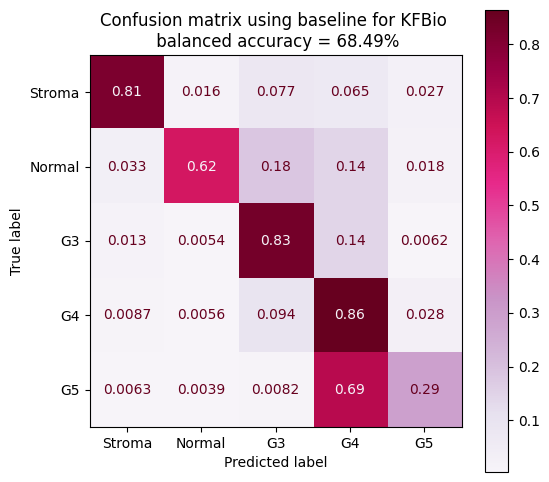

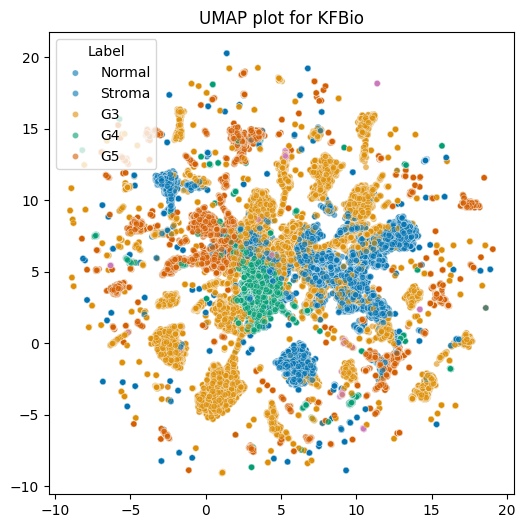

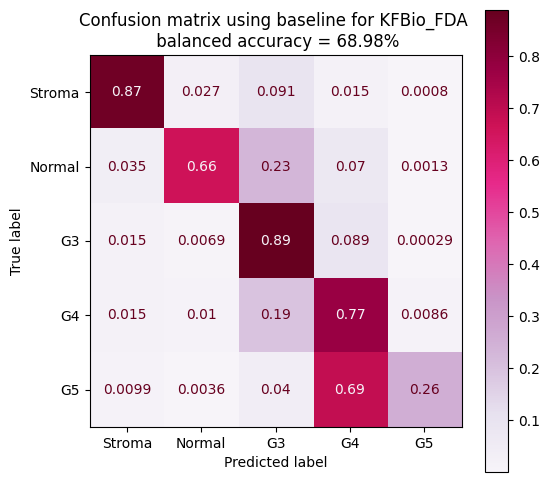

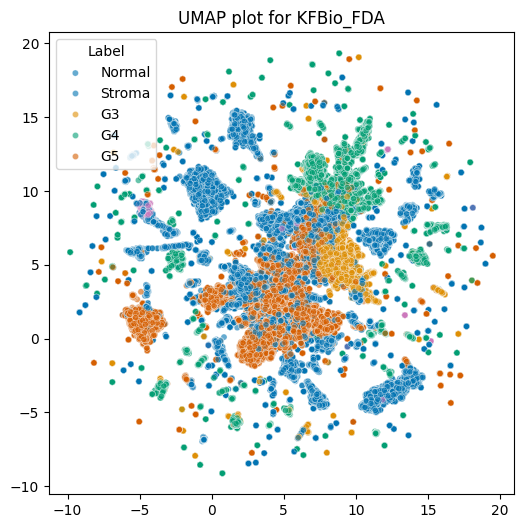

In [14]:
#use KFBio train data because it possesses the equivalent FDA
inference = True

if inference:
    custom_name = 'baseline'
    batch_size = 64
    id_ranges = [i for i in range(1, 26+1)]
    
    scanner = 'KFBio'
    loader = make_multi_WSI_dataset('Subset3', WSI_ids=id_ranges, scanners=[scanner], train_or_test='Train', batch_size=batch_size)
    loader = DataLoader(loader, batch_size=batch_size, num_workers=6, pin_memory=True, persistent_workers=True)
    handler = NetworkHandler(emb_mode=True)
    handler.inference(custom_name=custom_name, scanner=scanner, data_loader=loader, visual=True)
    
    scanner = 'KFBio_FDA'
    loader = make_multi_WSI_dataset('Subset3', WSI_ids=id_ranges, scanners=[scanner], train_or_test='Train', batch_size=batch_size)
    loader = DataLoader(loader, batch_size=batch_size, num_workers=6, pin_memory=True, persistent_workers=True)
    handler = NetworkHandler(emb_mode=True)
    handler.inference(custom_name=custom_name, scanner=scanner, data_loader=loader, visual=True)

Inference in progress...: 100%|████████████████████████████████████████████████████████████████| 13670/13670 [01:37<00:00, 140.66it/s]


0.7526222067888142


/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(init='random', n_jobs=1, random_state=42, verbose=True)
Mon Sep  1 10:56:00 2025 Construct fuzzy simplicial set
Mon Sep  1 10:56:01 2025 Finding Nearest Neighbors
Mon Sep  1 10:56:01 2025 Building RP forest with 26 trees
Mon Sep  1 10:56:20 2025 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	 4  /  17
	 5  /  17
	 6  /  17
	Stopping threshold met -- exiting after 6 iterations
Mon Sep  1 10:56:43 2025 Finished Nearest Neighbor Search
Mon Sep  1 10:56:45 2025 Construct embedding


Epochs completed:   2%| █▉                                                                                               4/200 [00:00]

...

Epochs completed:  90%| █████████████████████████████████████████████████████████████████████████████████████          181/200 [00:58]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████████████████████████████████████████████████████████████████████████████████████████ 200/200 [01:05]


Mon Sep  1 11:02:11 2025 Finished embedding


/tmp/ipykernel_2139217/2739345910.py:49: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  ax = sns.scatterplot(


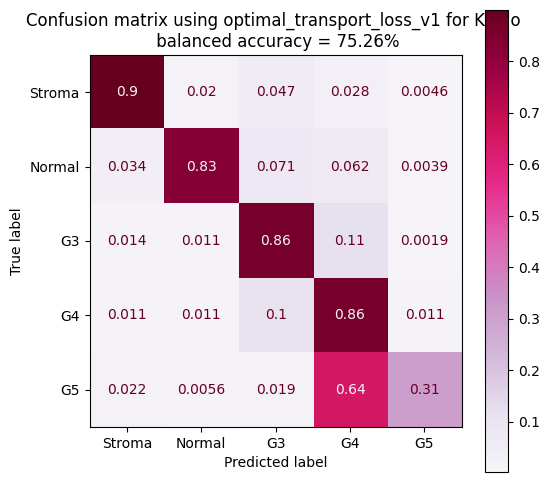

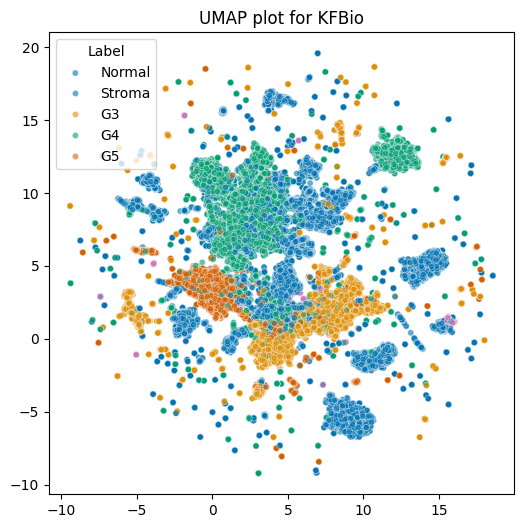

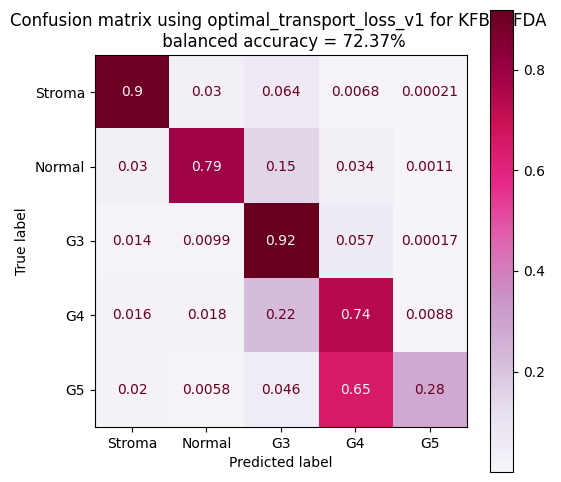

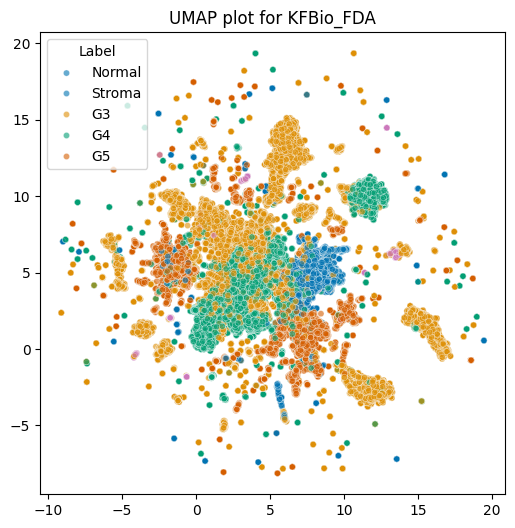

In [15]:
inference = True

if inference:
    custom_name = 'optimal_transport_loss_v1'
    batch_size = 64
    id_ranges = [i for i in range(1, 26+1)]
    
    scanner = 'KFBio'
    loader = make_multi_WSI_dataset('Subset3', WSI_ids=id_ranges, scanners=[scanner], train_or_test='Train', batch_size=batch_size)
    loader = DataLoader(loader, batch_size=batch_size, num_workers=6, pin_memory=True, persistent_workers=True)
    handler = NetworkHandler(emb_mode=True)
    handler.inference(custom_name=custom_name, scanner=scanner, data_loader=loader, visual=True)
    
    scanner = 'KFBio_FDA'
    loader = make_multi_WSI_dataset('Subset3', WSI_ids=id_ranges, scanners=[scanner], train_or_test='Train', batch_size=batch_size)
    loader = DataLoader(loader, batch_size=batch_size, num_workers=6, pin_memory=True, persistent_workers=True)
    handler = NetworkHandler(emb_mode=True)
    handler.inference(custom_name=custom_name, scanner=scanner, data_loader=loader, visual=True)